In [1]:
# yfinance means yahoo finance its a library which allows to fetch real time data from yahoo finance 

!pip install yfinance 

============= Complete Stock Analyzer =============


 Enter the stock symbol (or Q to quit): RELIANCE.NS



 -------------------------------------
 Company : Reliance Industries Limited
 Current Price : 1380.7 INR
 Change : -11.50 (-0.83%)

 -------------------------------------


[*********************100%***********************]  1 of 1 completed


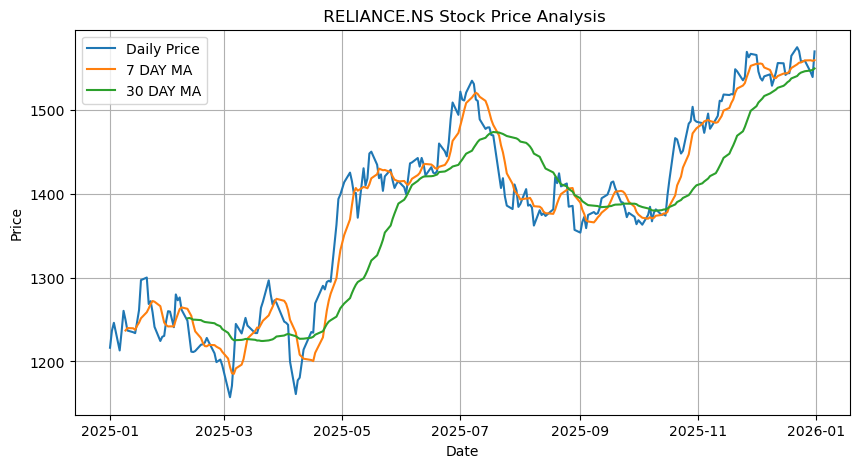

In [ ]:
# import the libraries 

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf 

print("============= Complete Stock Analyzer =============")

while True :
    
    # step 1 : take the input of the stock symbol ( every company has its short stock name )

    symbol = input(" Enter the stock symbol (or Q to quit):").upper()

    if symbol == "Q":
        print("Exiting program ...")
        break 

    try:

        # Ticker is a function which is used to search the website about it 
        # here it takes the symbol and searches for it on yfinance
        # whatever symbol it gets it saves it in stock variable 
        stock = yf.Ticker(symbol)
        # all the information regarding that symbol company it will be stored in info var 
        info = stock.info 
        
        name = info.get("longName","N/A")
        price = info.get("currentPrice")
        prev_close = info.get("previousClose")
        currency = info.get("currency","USD")

        print("\n -------------------------------------")
        print(f" Company : {name}")
        print(f" Current Price : {price} {currency}")
        
        if price and prev_close:
            # change in price
            change = price - prev_close
            # percent change 
            percent = ( change/prev_close)*100

            print(f" Change : {change:+.2f} ({percent:+.2f}%)")
            

        print("\n -------------------------------------")

        # Dowmload the historical Data
        # store it in the df variable 
        
        df= yf.download(symbol, start="2025-01-01", end="2026-01-01", interval = "1d")
        
        # Moving Averages : to smooth out the extreme  peaks and lows 

        #rolling in df["Close"].rolling(window=7) means creating a sliding window of 7 rows (days) over the "Close" column.
        #- Calculates something (like mean) for days 1-7, then 2-8, 3-9...

        # Calculate 7-day Moving Average of 'Close' prices
        df["7_day_MA"] = df["Close"].rolling(window=7).mean()

        # Calculate 30-day Moving Average of 'Close' prices
        df["30_day_MA"] = df["Close"].rolling(window=30).mean()

        # Plot the Graph

        plt.figure(figsize=(10,5))
        plt.plot(df["Close"],label = "Daily Price")
        plt.plot(df["7_day_MA"],label = "7 DAY MA")
        plt.plot(df["30_day_MA"],label = "30 DAY MA")

        plt.title(f" {symbol} Stock Price Analysis")
        plt.xlabel("Date")
        plt.ylabel("Price")
        plt.legend()
        plt.grid(True)
        plt.show()


        
    except Exception as e:
        print("Invalid Symbol or network error\n")